In [1]:
import librosa
import numpy as np
import pandas as pd
import scipy

In [2]:
import nest_asyncio
import asyncio

In [3]:
import ssl

In [4]:
import os
import sys
import re
import tempfile

In [5]:
import pyaudio
from IPython.display import Audio, display
from ipywidgets import Button

In [6]:
from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import FileResponse, HTMLResponse, RedirectResponse
from fastapi.staticfiles import StaticFiles
from fastapi.staticfiles import StaticFiles
import uvicorn

In [7]:
import seaborn as sns

In [8]:
import tensorflow as tf
import kagglehub

I0000 00:00:1779698252.903111   16055 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779698253.027015   16055 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779698256.296939   16055 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Loading in all the data from the horns dataset

In [9]:
anchoring_data = pd.read_csv('horns/labels.csv')
#anchoring_data = anchoring_data[:-3]
anchoring_data

,file_name,labels
0,12-VIBROMAX-VX-PAIR.mp3,CAR/TRUCK
1,5-MEGASONIC-MS-PAIR.mp3,CAR/TRUCK/BUS
2,19-Supersonic-SS-PAIR.mp3,CAR/TRUCK/JEEP
3,RSA2-Pair.mp3,CAR/TRUCK
4,14-VIBROSONIC-VS-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR
5,20-R125-R125-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR
6,Supertone-Pair.mp3,CAR/TWO WHEELER
7,13-VIBROMINI-VM-PAIR.mp3,CAR/TRACTOR/TWO WHEELER
8,11-SPIDER-ECO-BLACK-SE-PAIR.mp3,TWO WHEELER/CAR/JEEP
9,1-CLEARTONE-BLACK-CB-PAIR.mp3,TWO WHEELER/CAR/JEEP


In [10]:
audio, _ = librosa.load('horns/CLEARTONE-MINI.mp3', sr=16000, mono=True)
audio

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

<Axes: >

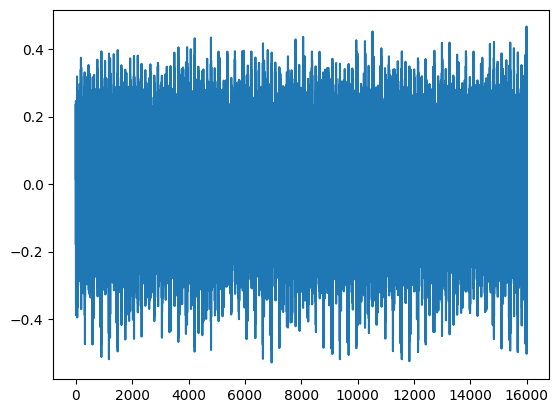

In [11]:
sns.lineplot(audio[5 * 16000: 6 * 16000])

In [12]:
def usable_data(fn):
    audio, sr = librosa.load(os.path.join('horns', fn), sr=16000, mono=True)
    return audio[5 * sr : 6 * sr]

anchoring_data['audio'] = anchoring_data['file_name'].apply(usable_data)

In [13]:
anchoring_data

,file_name,labels,audio
0,12-VIBROMAX-VX-PAIR.mp3,CAR/TRUCK,"[0.27441505, -0.21807452, -0.21259846, 0.11278..."
1,5-MEGASONIC-MS-PAIR.mp3,CAR/TRUCK/BUS,"[0.27104467, -0.0011240095, -0.45411745, -0.37..."
2,19-Supersonic-SS-PAIR.mp3,CAR/TRUCK/JEEP,"[-0.43138474, -0.41799343, 0.20755395, 0.54530..."
3,RSA2-Pair.mp3,CAR/TRUCK,"[-0.082663134, -0.20827158, -0.109646335, 0.02..."
4,14-VIBROSONIC-VS-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[-0.24529836, 0.29467046, 0.35949934, -0.13011..."
5,20-R125-R125-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[0.366105, 0.5941705, 0.0014196038, -0.5461574..."
6,Supertone-Pair.mp3,CAR/TWO WHEELER,"[-0.10557088, 0.23596989, 0.40089506, 0.228630..."
7,13-VIBROMINI-VM-PAIR.mp3,CAR/TRACTOR/TWO WHEELER,"[-0.00027319358, -0.00021853978, -0.0001354827..."
8,11-SPIDER-ECO-BLACK-SE-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[-0.19487502, 0.0147623755, 0.21202356, 0.0716..."
9,1-CLEARTONE-BLACK-CB-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[0.14891195, -0.12898393, -0.16490954, 0.07717..."


## Load YAMNet and encodings

In [14]:
yamnet_model_download = kagglehub.model_download('google/yamnet/tensorFlow2/yamnet')
yamnet = tf.saved_model.load(yamnet_model_download)

classes_path = os.path.join(yamnet_model_download, 'assets/yamnet_class_map.csv')
classes = pd.read_csv(classes_path)

E0000 00:00:1779698266.038138   16055 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
_, embed, _ = yamnet(audio[5 * 16000 : 6 * 16000])
embed.numpy().mean(axis=0)

array([0.        , 0.        , 0.14916019, ..., 0.721987  , 0.        ,
       0.        ], dtype=float32)

In [16]:
def gen_anchors(ad):
    _, embeddings, _ = yamnet(ad)
    return embeddings.numpy()[0]
anchoring_data['embedding'] = anchoring_data['audio'].apply(gen_anchors)

In [17]:
anchoring_data

,file_name,labels,audio,embedding
0,12-VIBROMAX-VX-PAIR.mp3,CAR/TRUCK,"[0.27441505, -0.21807452, -0.21259846, 0.11278...","[0.0, 0.0, 0.08300633, 2.9436324, 0.0, 0.0, 0...."
1,5-MEGASONIC-MS-PAIR.mp3,CAR/TRUCK/BUS,"[0.27104467, -0.0011240095, -0.45411745, -0.37...","[0.0, 0.0, 0.0, 2.9426756, 0.0, 0.0, 0.0, 3.91..."
2,19-Supersonic-SS-PAIR.mp3,CAR/TRUCK/JEEP,"[-0.43138474, -0.41799343, 0.20755395, 0.54530...","[0.0, 0.0, 0.0, 1.9778099, 0.0, 0.0, 0.0, 3.66..."
3,RSA2-Pair.mp3,CAR/TRUCK,"[-0.082663134, -0.20827158, -0.109646335, 0.02...","[0.0, 0.0, 0.007266792, 1.892058, 0.0, 0.0, 0...."
4,14-VIBROSONIC-VS-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[-0.24529836, 0.29467046, 0.35949934, -0.13011...","[0.0, 0.0, 0.0, 1.5934153, 0.0, 0.0, 0.0, 2.29..."
5,20-R125-R125-PAIR.mp3,CAR/TRUCK/JEEP/TRACTOR,"[0.366105, 0.5941705, 0.0014196038, -0.5461574...","[0.0, 0.0, 0.19576246, 1.3435559, 0.0, 0.0, 0...."
6,Supertone-Pair.mp3,CAR/TWO WHEELER,"[-0.10557088, 0.23596989, 0.40089506, 0.228630...","[0.0, 0.0, 0.14112741, 0.047581673, 0.0, 0.0, ..."
7,13-VIBROMINI-VM-PAIR.mp3,CAR/TRACTOR/TWO WHEELER,"[-0.00027319358, -0.00021853978, -0.0001354827...","[0.0, 0.0, 0.0, 1.6880398, 0.0, 0.0, 0.0, 1.92..."
8,11-SPIDER-ECO-BLACK-SE-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[-0.19487502, 0.0147623755, 0.21202356, 0.0716...","[0.0, 0.0, 0.0, 0.91740847, 0.0, 0.0, 0.0, 0.0..."
9,1-CLEARTONE-BLACK-CB-PAIR.mp3,TWO WHEELER/CAR/JEEP,"[0.14891195, -0.12898393, -0.16490954, 0.07717...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5182071,..."


In [18]:
def get_top_percentile(scores, p = 0.95):
    select_best = np.argsort(scores)[::-1]
    
    total = np.sum(scores)
    indx = np.argmax(np.cumsum(scores.numpy()[select_best] / total) >= p) + 1

    snap = ' | '.join(classes['display_name'][select_best][:indx])

    vehicle_type = re.search(r'Car|Truck|Bus|Motor|Vehicle', snap, re.IGNORECASE)
    horn = re.search(r'Alarm|Toot|Horn|Honk|Buzzer|Siren|Bell', snap, re.IGNORECASE)

    spoof = 'Nope'
    if horn:
        spoof = horn.group()
        if vehicle_type:
            spoof += ' | ' + vehicle_type.group()

    return *classes['display_name'][select_best][:5], spoof, np.sum(scores.numpy()[select_best[:5]]) / total

In [19]:
def get_horn_distances(embed):
    T = 2.5
    distances = anchoring_data['embedding'].apply(lambda a: -scipy.spatial.distance.euclidean(a, embed))
    probs = scipy.special.softmax(distances)
    return probs

In [20]:
adev = pyaudio.PyAudio()
stream = adev.open(rate=16000, channels=1, format=pyaudio.paFloat32, input=True, frames_per_buffer=16000)
rec = stream.read(num_frames=16000 * 10, exception_on_overflow=False)
stream.close()
audio = np.frombuffer(rec, dtype=np.float32)
Audio(audio, rate=16000)

ALSA lib pcm_dsnoop.c:567:(snd_pcm_dsnoop_open) unable to open slave
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock


In [21]:
scores, embeddings, _ = yamnet(audio)

In [22]:
get_top_percentile(scores[11], 0.9)

('Speech',
 'Conversation',
 'Narration, monologue',
 'Inside, large room or hall',
 'Inside, small room',
 'Nope',
 0.9970437)

In [23]:
results = pd.DataFrame(range(0, len(scores), 1), columns=['time'])
extra = pd.DataFrame(list(map(lambda indx: get_top_percentile(scores[indx], 0.9), results['time'])), columns=['guess 1',
                                                                                                              'guess 2',
                                                                                                              'guess 3',
                                                                                                              'guess 4',
                                                                                                              'guess 5',
                                                                                                              'classes',
                                                                                                              'confidence'])
results = results.join(extra)
results['time'] = results['time'].apply(lambda a: a / 2)
results

,time,guess 1,guess 2,guess 3,guess 4,guess 5,classes,confidence
0,0.0,"Inside, small room","Dishes, pots, and pans",Squish,Glass,Drip,Nope,0.554468
1,0.5,"Inside, small room",Speech,"Dishes, pots, and pans",Mechanisms,"Inside, large room or hall",Nope,0.679194
2,1.0,"Inside, small room",Silence,Speech,Mechanisms,Mechanical fan,Nope,0.424259
3,1.5,"Inside, small room",Silence,Speech,Animal,Cat,Alarm | vehicle,0.370109
4,2.0,"Inside, small room",Speech,Animal,"Inside, large room or hall","Domestic animals, pets",Nope,0.584488
5,2.5,"Inside, small room",Writing,"Domestic animals, pets",Animal,Silence,Nope,0.813594
6,3.0,"Inside, small room",Writing,Scissors,"Rodents, rats, mice",Animal,Nope,0.738144
7,3.5,"Inside, small room",Writing,"Inside, large room or hall",Mechanical fan,Squish,Nope,0.580618
8,4.0,"Inside, small room",Writing,Mechanisms,"Inside, large room or hall",Speech,Nope,0.617495
9,4.5,Speech,"Inside, small room","Inside, large room or hall","Narration, monologue",Conversation,Nope,0.991860


In [24]:
results.loc[5]

time                             2.5
guess 1           Inside, small room
guess 2                      Writing
guess 3       Domestic animals, pets
guess 4                       Animal
guess 5                      Silence
classes                         Nope
confidence                  0.813594
Name: 5, dtype: object

In [25]:
foo_labels = [ f'{a};{b.split('.')[0]}' for a, b in enumerate(anchoring_data['file_name'], start=1)]

In [26]:
alabs = pd.DataFrame(np.array(list(map(get_horn_distances, embeddings))), columns=foo_labels)
alabs

,1;12-VIBROMAX-VX-PAIR,2;5-MEGASONIC-MS-PAIR,3;19-Supersonic-SS-PAIR,4;RSA2-Pair,5;14-VIBROSONIC-VS-PAIR,6;20-R125-R125-PAIR,7;Supertone-Pair,8;13-VIBROMINI-VM-PAIR,9;11-SPIDER-ECO-BLACK-SE-PAIR,10;1-CLEARTONE-BLACK-CB-PAIR,...,20;18-WINDTONE-90-W90-PAIR,21;17-WINDTONE-75-VERTICAL-W75V-PAIR,22;W70-Pair,23;16-WINDTONE-75-W75-PAIR,24;Electronic-Horn,25;17-WINDTONE-75-ElectronicMulti-function-horn,26;Electromini,27;2-BACKUP-ALARM-TYPE-C,28;Backup-alarm-TYPE-BF,29;3-BACKUP-ALARM-TYPE-B
0,0.062412,0.000016,0.000235,0.035243,0.011323,0.000118,0.001000,0.000262,0.018529,0.004355,...,0.000063,0.000066,0.001651,0.000020,0.000020,0.043977,0.001191,0.057065,0.682559,0.058626
1,0.134695,0.000012,0.000193,0.062060,0.012091,0.000104,0.001056,0.000214,0.032450,0.004218,...,0.000052,0.000052,0.001578,0.000014,0.000014,0.083241,0.001267,0.075909,0.478994,0.095520
2,0.107961,0.000011,0.000214,0.067081,0.013925,0.000096,0.000858,0.000187,0.031662,0.004475,...,0.000039,0.000038,0.001535,0.000011,0.000011,0.073287,0.000954,0.068656,0.531286,0.081003
3,0.073561,0.000008,0.000148,0.039966,0.010446,0.000070,0.000659,0.000144,0.021178,0.003279,...,0.000030,0.000029,0.001077,0.000008,0.000008,0.051022,0.000656,0.059262,0.666536,0.059590
4,0.103614,0.000009,0.000153,0.059038,0.010204,0.000081,0.000808,0.000169,0.026631,0.003504,...,0.000044,0.000042,0.001394,0.000010,0.000010,0.083134,0.000911,0.067964,0.547349,0.081276
5,0.098727,0.000022,0.000327,0.050332,0.017027,0.000139,0.001237,0.000280,0.029093,0.005145,...,0.000063,0.000066,0.002523,0.000021,0.000021,0.079555,0.002119,0.086617,0.508305,0.096976
6,0.090767,0.000028,0.000373,0.048066,0.016945,0.000160,0.001302,0.000348,0.027968,0.005596,...,0.000086,0.000093,0.003144,0.000031,0.000031,0.078526,0.002502,0.084750,0.490520,0.122340
7,0.129968,0.000017,0.000269,0.058473,0.015178,0.000112,0.000874,0.000224,0.029897,0.003971,...,0.000058,0.000059,0.002195,0.000018,0.000018,0.083493,0.001714,0.056006,0.522903,0.074304
8,0.077029,0.000011,0.000181,0.042457,0.010822,0.000084,0.000853,0.000182,0.023111,0.003781,...,0.000043,0.000043,0.001562,0.000012,0.000012,0.061605,0.001113,0.071967,0.601113,0.088475
9,0.158587,0.000012,0.000193,0.075468,0.010693,0.000111,0.001214,0.000221,0.037626,0.004181,...,0.000069,0.000066,0.001668,0.000013,0.000013,0.118163,0.001486,0.077839,0.420819,0.076348


In [27]:
results['anchor_horn'] = (alabs > 0.65).sum(axis=1)
results

,time,guess 1,guess 2,guess 3,guess 4,guess 5,classes,confidence,anchor_horn
0,0.0,"Inside, small room","Dishes, pots, and pans",Squish,Glass,Drip,Nope,0.554468,1
1,0.5,"Inside, small room",Speech,"Dishes, pots, and pans",Mechanisms,"Inside, large room or hall",Nope,0.679194,0
2,1.0,"Inside, small room",Silence,Speech,Mechanisms,Mechanical fan,Nope,0.424259,0
3,1.5,"Inside, small room",Silence,Speech,Animal,Cat,Alarm | vehicle,0.370109,1
4,2.0,"Inside, small room",Speech,Animal,"Inside, large room or hall","Domestic animals, pets",Nope,0.584488,0
5,2.5,"Inside, small room",Writing,"Domestic animals, pets",Animal,Silence,Nope,0.813594,0
6,3.0,"Inside, small room",Writing,Scissors,"Rodents, rats, mice",Animal,Nope,0.738144,0
7,3.5,"Inside, small room",Writing,"Inside, large room or hall",Mechanical fan,Squish,Nope,0.580618,0
8,4.0,"Inside, small room",Writing,Mechanisms,"Inside, large room or hall",Speech,Nope,0.617495,0
9,4.5,Speech,"Inside, small room","Inside, large room or hall","Narration, monologue",Conversation,Nope,0.991860,0


In [28]:
(alabs > 0.6).sum()

1;12-VIBROMAX-VX-PAIR                              0
2;5-MEGASONIC-MS-PAIR                              0
3;19-Supersonic-SS-PAIR                            0
4;RSA2-Pair                                        0
5;14-VIBROSONIC-VS-PAIR                            0
6;20-R125-R125-PAIR                                0
7;Supertone-Pair                                   0
8;13-VIBROMINI-VM-PAIR                             0
9;11-SPIDER-ECO-BLACK-SE-PAIR                      0
10;1-CLEARTONE-BLACK-CB-PAIR                       0
11;21-R100-R100-PAIR                               0
12;6-R-95-R95-PAIR                                 0
13;CLEARTONE-MINI                                  0
14;8-ROOTS-90-R90-PAIR                             0
15;10-SMARTONE-SM70-PAIR                           0
16;R82-Pair                                        0
17;7-ROOTS-75-R75-PAIR                             0
18;22-R70-NEW-R70-NEW-PAIR                         0
19;9-S70-S70-PAIR                             

## Setting up a server using fastapi

In [29]:
app = FastAPI()
origins = ['*']
app.add_middleware(
    CORSMiddleware,
    allow_origins=origins,
    allow_credentials=True,
    allow_methods=['*'],
    allow_headers=['*']
)

In [30]:
app.mount("/static", StaticFiles(directory="static"), name="static")

In [31]:
@app.get("/")
async def redirect_typer():
    return RedirectResponse("/static/index.html")

In [32]:
@app.post('/recognize')
async def get_predictions(file : UploadFile = File()):
    with tempfile.NamedTemporaryFile(suffix='.webm') as foo:
        foo.write(file.file.read())
        foo.flush()

        audio_data, _ = librosa.load(foo.name, sr=16000, mono=True)
        scores, embeddings, spectogram = yamnet(audio_data)

        results = pd.DataFrame(range(0, len(scores), 1), columns=['time'])
        extra = pd.DataFrame(list(map(lambda indx: get_top_percentile(scores[indx], 0.75), results['time'])), columns=['guess 1',
                                                                                                              'guess 2',
                                                                                                              'guess 3',
                                                                                                              'guess 4',
                                                                                                              'guess 5',
                                                                                                              'classes',
                                                                                                              'confidence'])
        results = results.join(extra)
        results['time'] = results['time'].apply(lambda a: a / 2)
        
        foo_labels = [ f'{a};{b}' for a, b in enumerate(anchoring_data['file_name'], start=1)]
        alabs = pd.DataFrame(np.array(list(map(get_horn_distances, embeddings))), columns=foo_labels)

        results['anchor_horn'] = (alabs > 0.4).sum(axis=1)

        summary = (alabs > 0.4).sum()

        return {'result': results.to_dict(), 'summary': summary.to_dict()}

In [33]:
serv_config = uvicorn.Config(app, host="0.0.0.0", port=8080, ssl_keyfile='key.pem', ssl_certfile='cert.pem')
server = uvicorn.Server(serv_config)

In [34]:
nest_asyncio.apply()

In [35]:
def launch_server():
    loop = asyncio.get_event_loop()
    loop.create_task(server.serve())

In [36]:
def drop_server():
    asyncio.create_task(server.shutdown())

In [41]:
#launch_server()

In [42]:
#drop_server()